# 002 – Stockout Timing & Drivers Analysis
**SunnyBest Forecasting System (SFS)**

---

## Focus
**When do stockouts occur? Do promotions drive them? Is low inventory a consistent driver?**

## Questions to Answer
1. Which month(s) have the highest stockout rate? Is it driven by seasonal demand or promotions?
2. Does the day of week matter? Are weekends worse (higher foot traffic)?
3. Is there a clear positive relationship between promotion activity and stockout rate?
4. What starting inventory level is the cut-off — below which stockout risk shoots up? *(reorder threshold)*
5. Which restriction type correlates most with stockouts?

---

## 0. Setup

In [1]:
import subprocess, sys
for pkg in ['pandas','numpy','matplotlib','seaborn','sqlalchemy','psycopg2-binary','scipy']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('Packages ready.')


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


Packages ready.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sqlalchemy import create_engine
from urllib.parse import quote_plus

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)

---
## 1. Database Connection

In [4]:
host     = "aws-1-eu-central-1.pooler.supabase.com"
port     = 5432
database = "postgres"
user     = "uddy.ogkdfmkybqtrsglcizzt"
password = quote_plus("Uddodirim123")

engine = create_engine(
    f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}",
    pool_pre_ping=True,
    connect_args={"options": "-c statement_timeout=300000"}
)

test = pd.read_sql("SELECT current_user, current_database()", engine)
print("Connected as:", test.iloc[0, 0], "| DB:", test.iloc[0, 1])

Connected as: uddy | DB: postgres


---
## 2. Load Data

In [5]:
# fact_sales — sampled at 10% for speed, enriched with calendar fields
df_sales = pd.read_sql("""
    SELECT
        s.date,
        s.store_id,
        s.product_id,
        s.units_sold,
        s.stockout_occurred,
        s.promo_flag,
        s.starting_inventory,
        s.ending_inventory,
        s.restriction_active,
        s.restriction_type,
        s.category,
        s.store_type,
        s.store_size,
        c.month,
        c.day_of_week,
        c.is_weekend,
        c.is_holiday,
        c.is_payday,
        c.season,
        c.is_black_friday_period
    FROM core.fact_sales s
    TABLESAMPLE BERNOULLI(10)
    JOIN core.dim_calendar c ON s.date = c.date
""", engine, parse_dates=['date'])

# fact_promotions — full (small table)
df_promos = pd.read_sql("""
    SELECT date, store_id, product_id, promo_type, discount_pct, promo_flag
    FROM core.fact_promotions
    ORDER BY date
""", engine, parse_dates=['date'])

# fact_restriction_events — full
df_restrictions = pd.read_sql("""
    SELECT date, store_id, product_id, restriction_type, restriction_severity, duration_days
    FROM core.fact_restriction_events
    ORDER BY date
""", engine, parse_dates=['date'])

print(f"fact_sales sample:        {df_sales.shape[0]:,} rows")
print(f"fact_promotions:          {df_promos.shape[0]:,} rows")
print(f"fact_restriction_events:  {df_restrictions.shape[0]:,} rows")
print(f"\nDate range: {df_sales['date'].min().date()} → {df_sales['date'].max().date()}")

fact_sales sample:        163,584 rows
fact_promotions:          380 rows
fact_restriction_events:  22,136 rows

Date range: 2021-01-01 → 2026-05-09


---
## 3. Baseline Stockout Rate
*Overall picture before drilling into drivers.*

In [6]:
overall_rate = df_sales['stockout_occurred'].mean() * 100
print(f"Overall stockout rate: {overall_rate:.1f}%")
print(f"Total rows:            {len(df_sales):,}")
print(f"Stockout rows:         {df_sales['stockout_occurred'].sum():,}")
print(f"No-stockout rows:      {(df_sales['stockout_occurred']==0).sum():,}")

Overall stockout rate: 6.1%
Total rows:            163,584
Stockout rows:         9,943
No-stockout rows:      153,641


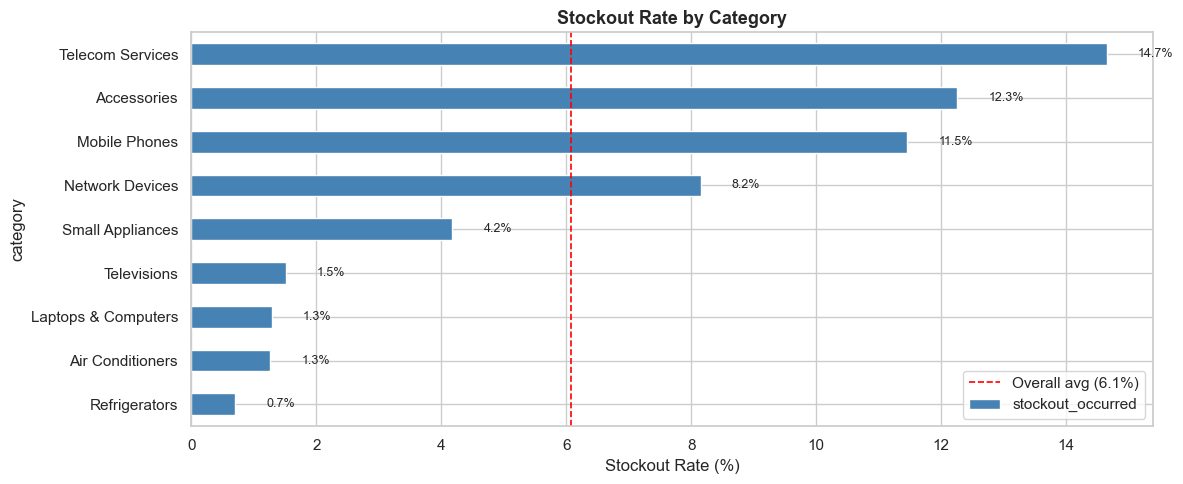

In [7]:
# Stockout rate by category — baseline for comparison
cat_rate = (
    df_sales.groupby('category')['stockout_occurred']
    .mean()
    .mul(100)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = cat_rate.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.axvline(overall_rate, color='red', linestyle='--', linewidth=1.2, label=f'Overall avg ({overall_rate:.1f}%)')
ax.set_title('Stockout Rate by Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Stockout Rate (%)')
ax.legend()
for i, v in enumerate(cat_rate):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 4. Q1 – Which Month(s) Have the Highest Stockout Rate?
*Is it seasonal demand or promotion-driven?*

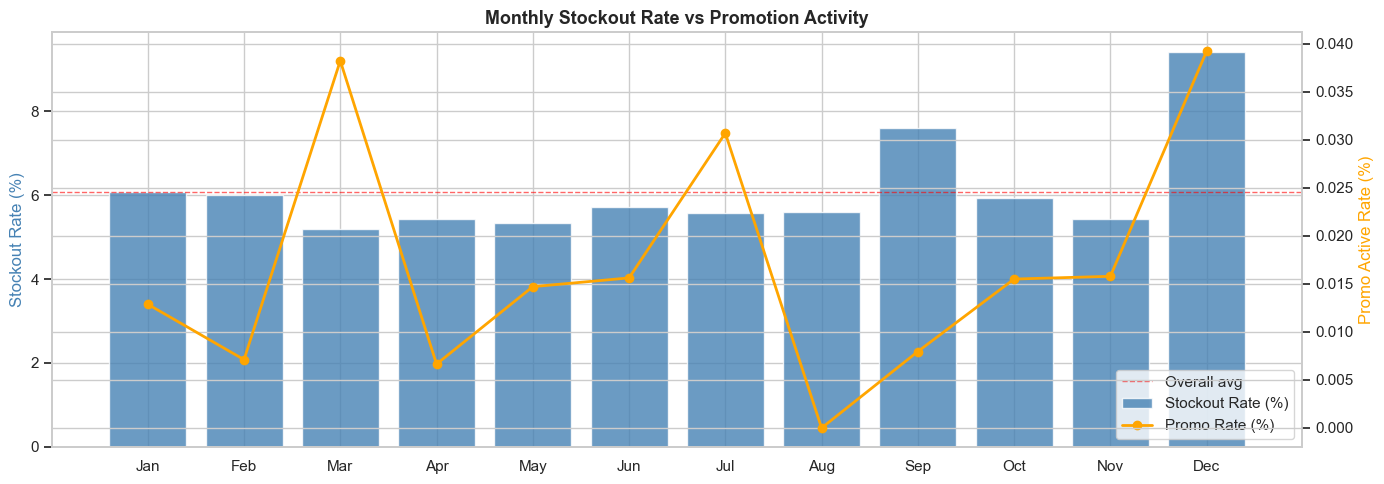


Monthly breakdown:
month_name  stockout_rate  promo_rate  total_rows
       Jan         6.0813      0.0129       15523
       Feb         6.0041      0.0071       14057
       Mar         5.1867      0.0382       15694
       Apr         5.4392      0.0066       15039
       May         5.3476      0.0147       13595
       Jun         5.7257      0.0156       12802
       Jul         5.5790      0.0307       13031
       Aug         5.6061      0.0000       12968
       Sep         7.6023      0.0080       12562
       Oct         5.9298      0.0155       12901
       Nov         5.4398      0.0158       12666
       Dec         9.4147      0.0392       12746


In [8]:
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

monthly = df_sales.groupby('month').agg(
    stockout_rate=('stockout_occurred', 'mean'),
    promo_rate=('promo_flag', 'mean'),
    total_rows=('stockout_occurred', 'count')
).reset_index()
monthly['stockout_rate'] *= 100
monthly['promo_rate']    *= 100
monthly['month_name'] = monthly['month'].map(month_names)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(monthly['month_name'], monthly['stockout_rate'], color='steelblue', alpha=0.8, label='Stockout Rate (%)')
ax2.plot(monthly['month_name'], monthly['promo_rate'], color='orange', marker='o', linewidth=2, label='Promo Rate (%)')

ax1.set_ylabel('Stockout Rate (%)', color='steelblue')
ax2.set_ylabel('Promo Active Rate (%)', color='orange')
ax1.set_title('Monthly Stockout Rate vs Promotion Activity', fontsize=13, fontweight='bold')
ax1.axhline(overall_rate, color='red', linestyle='--', linewidth=1, alpha=0.6, label=f'Overall avg')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')
plt.tight_layout()
plt.show()

print("\nMonthly breakdown:")
print(monthly[['month_name','stockout_rate','promo_rate','total_rows']].to_string(index=False))

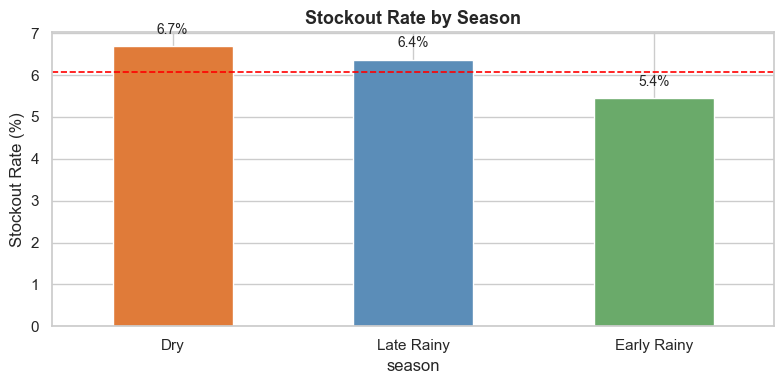

In [9]:
# Monthly stockout rate by season
season_rate = (
    df_sales.groupby('season')['stockout_occurred']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
season_rate.plot(kind='bar', ax=ax, color=['#e07b39','#5b8db8','#6aaa6a'], edgecolor='white')
ax.axhline(overall_rate, color='red', linestyle='--', linewidth=1.2)
ax.set_title('Stockout Rate by Season', fontsize=13, fontweight='bold')
ax.set_ylabel('Stockout Rate (%)')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(season_rate):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 5. Q2 – Does Day of Week Matter?
*Are weekends worse due to higher foot traffic?*

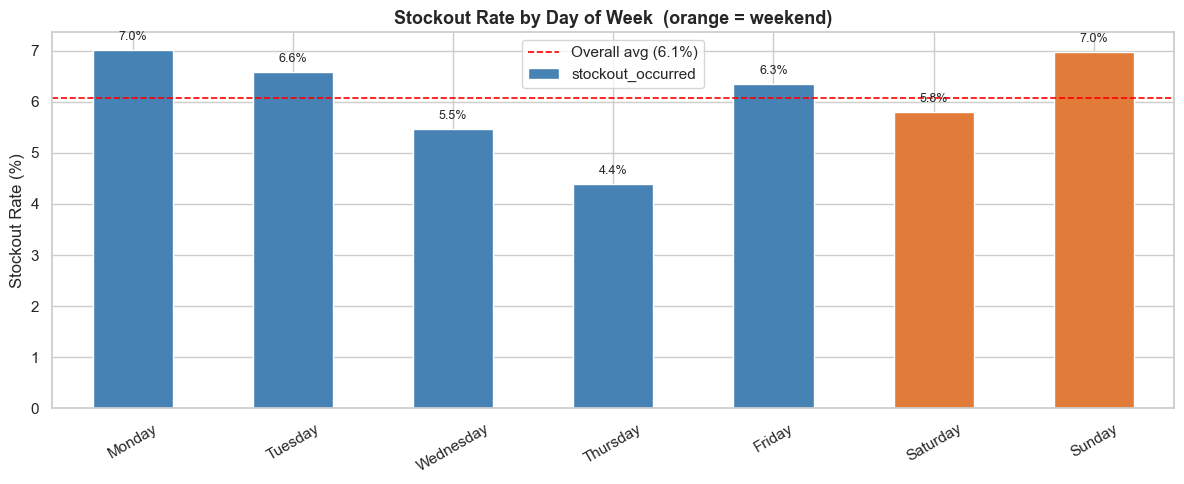


Weekday vs Weekend stockout rate:
  Weekday:  5.96%
  Weekend:  6.38%


In [11]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

dow_rate = (
    df_sales.groupby('day_of_week')['stockout_occurred']
    .mean()
    .mul(100)
    .reindex(day_order)
)

colors = ['#e07b39' if d in ['Saturday','Sunday'] else 'steelblue' for d in day_order]

fig, ax = plt.subplots(figsize=(12, 5))
dow_rate.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.axhline(overall_rate, color='red', linestyle='--', linewidth=1.2, label=f'Overall avg ({overall_rate:.1f}%)')
ax.set_title('Stockout Rate by Day of Week  (orange = weekend)', fontsize=13, fontweight='bold')
ax.set_ylabel('Stockout Rate (%)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.legend()
for i, v in enumerate(dow_rate):
    ax.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# Weekday vs weekend
weekend_rate = df_sales.groupby('is_weekend')['stockout_occurred'].mean().mul(100)
print("\nWeekday vs Weekend stockout rate:")
print(f"  Weekday:  {weekend_rate.get(False, weekend_rate.get(0, 0)):.2f}%")
print(f"  Weekend:  {weekend_rate.get(True, weekend_rate.get(1, 0)):.2f}%")

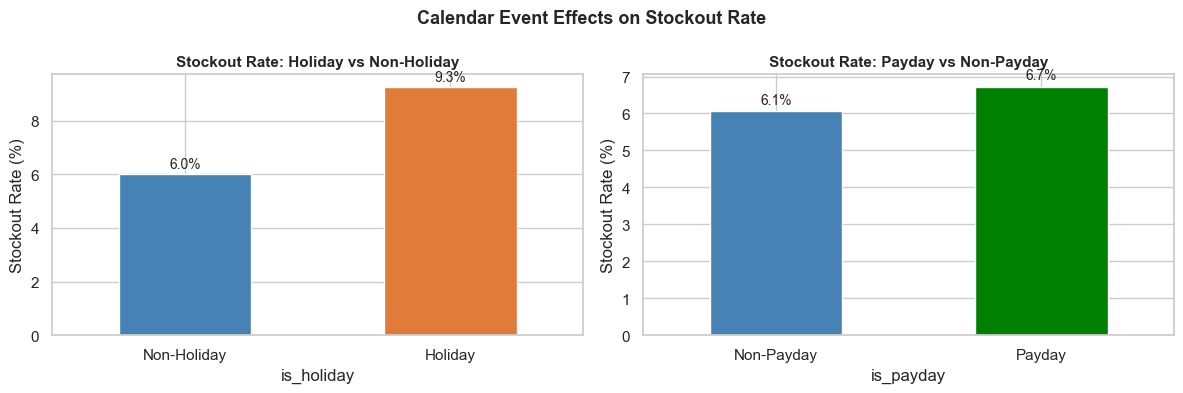

In [13]:
# Holiday and payday effects
holiday_rate = df_sales.groupby('is_holiday')['stockout_occurred'].mean().mul(100)
payday_rate  = df_sales.groupby('is_payday')['stockout_occurred'].mean().mul(100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

holiday_rate.plot(kind='bar', ax=axes[0], color=['steelblue','#e07b39'], edgecolor='white')
axes[0].set_title('Stockout Rate: Holiday vs Non-Holiday', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Stockout Rate (%)')
axes[0].set_xticklabels(['Non-Holiday','Holiday'], rotation=0)
for i, v in enumerate(holiday_rate):
    axes[0].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=10)

payday_rate.plot(kind='bar', ax=axes[1], color=['steelblue','green'], edgecolor='white')
axes[1].set_title('Stockout Rate: Payday vs Non-Payday', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Stockout Rate (%)')
axes[1].set_xticklabels(['Non-Payday','Payday'], rotation=0)
for i, v in enumerate(payday_rate):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=10)

plt.suptitle('Calendar Event Effects on Stockout Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Q3 – Do Promotions Drive Stockouts?
*Is there a clear positive relationship between promotion activity and stockout rate?*

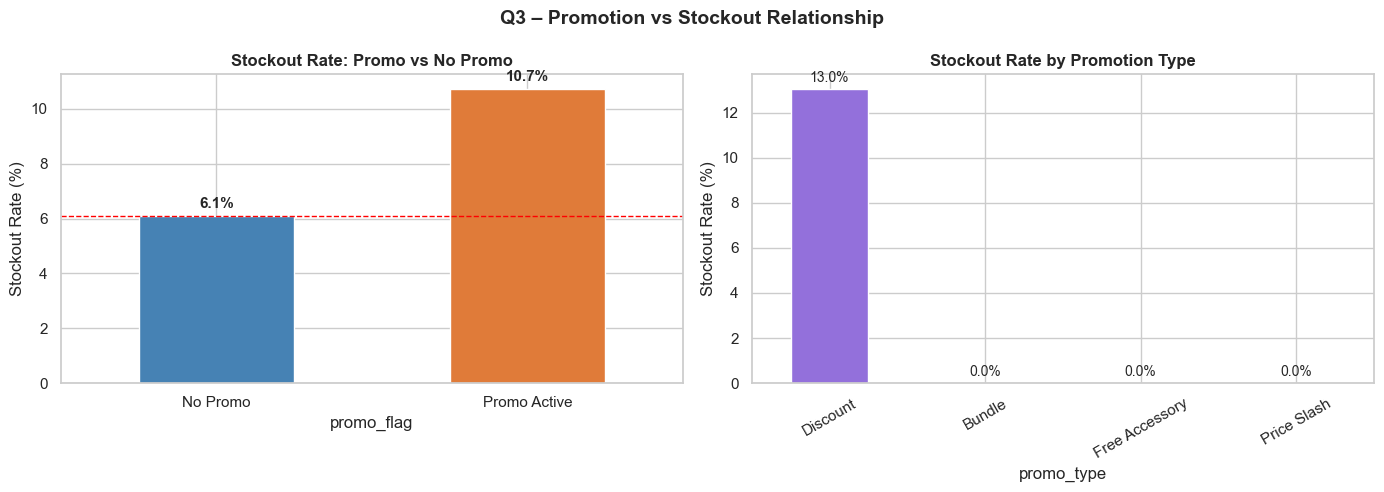

In [14]:
promo_stockout = df_sales.groupby('promo_flag')['stockout_occurred'].mean().mul(100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stockout rate: promo vs no promo
promo_stockout.plot(kind='bar', ax=axes[0], color=['steelblue','#e07b39'], edgecolor='white', width=0.5)
axes[0].set_title('Stockout Rate: Promo vs No Promo', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Stockout Rate (%)')
axes[0].set_xticklabels(['No Promo','Promo Active'], rotation=0)
axes[0].axhline(overall_rate, color='red', linestyle='--', linewidth=1)
for i, v in enumerate(promo_stockout):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Stockout rate by promo type (from fact_promotions joined)
promo_merged = df_sales.merge(
    df_promos[['date','store_id','product_id','promo_type','discount_pct']],
    on=['date','store_id','product_id'], how='left'
)
promo_type_rate = (
    promo_merged[promo_merged['promo_type'].notna()]
    .groupby('promo_type')['stockout_occurred']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

if len(promo_type_rate) > 0:
    promo_type_rate.plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='white')
    axes[1].set_title('Stockout Rate by Promotion Type', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Stockout Rate (%)')
    axes[1].tick_params(axis='x', rotation=30)
    for i, v in enumerate(promo_type_rate):
        axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)
else:
    axes[1].text(0.5, 0.5, 'No promo type matches in sample', ha='center', transform=axes[1].transAxes)
    axes[1].set_title('Stockout Rate by Promotion Type', fontsize=12)

plt.suptitle('Q3 – Promotion vs Stockout Relationship', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Monthly: stockout rate vs promo rate — correlation test
corr, pval = stats.pearsonr(monthly['stockout_rate'], monthly['promo_rate'])
print(f"Pearson correlation (monthly stockout rate vs promo rate):")
print(f"  r = {corr:.3f}  |  p-value = {pval:.3f}")
if pval < 0.05:
    direction = 'positive' if corr > 0 else 'negative'
    print(f"  → Statistically significant {direction} correlation")
else:
    print(f"  → No statistically significant correlation (p > 0.05)")

# Category-level: does promo increase stockout within category?
cat_promo = (
    df_sales.groupby(['category','promo_flag'])['stockout_occurred']
    .mean()
    .mul(100)
    .unstack()
    .rename(columns={0:'No Promo',1:'Promo Active'})
)
cat_promo['Difference'] = cat_promo.get('Promo Active', 0) - cat_promo.get('No Promo', 0)
print("\nStockout rate by category — Promo vs No Promo:")
print(cat_promo.round(2).to_string())

Pearson correlation (monthly stockout rate vs promo rate):
  r = 0.317  |  p-value = 0.316
  → No statistically significant correlation (p > 0.05)

Stockout rate by category — Promo vs No Promo:
promo_flag           No Promo  Promo Active  Difference
category                                               
Accessories           12.2500       25.0000     12.7500
Air Conditioners       1.2600        0.0000     -1.2600
Laptops & Computers    1.2800        0.0000     -1.2800
Mobile Phones         11.4600        0.0000    -11.4600
Network Devices        8.1500       25.0000     16.8500
Refrigerators          0.7000           NaN         NaN
Small Appliances       4.1700       25.0000     20.8300
Telecom Services      14.6500        0.0000    -14.6500
Televisions            1.5100        0.0000     -1.5100


---
## 7. Q4 – Starting Inventory Cut-off (Reorder Threshold)
*At what starting inventory level does stockout risk shoot up?*

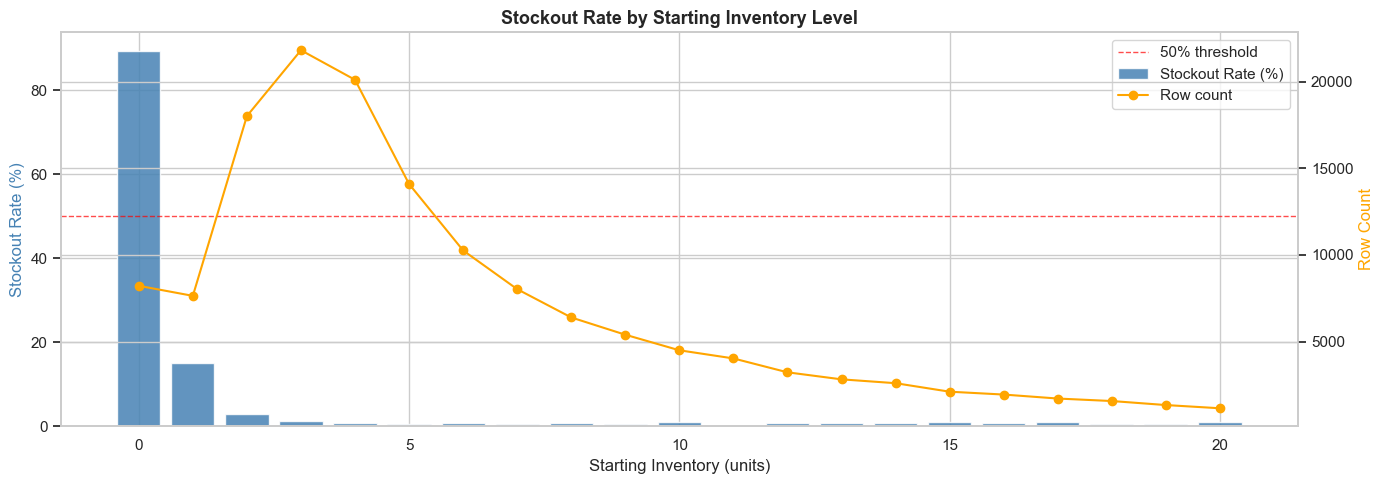


Stockout rate by starting inventory (0–20 units):
 starting_inventory  stockout_rate  count
                  0        89.2931   8219
                  1        14.9496   7639
                  2         2.8968  18020
                  3         1.1228  21821
                  4         0.6463  20114
                  5         0.5888  14096
                  6         0.7212  10260
                  7         0.5857   8025
                  8         0.6571   6392
                  9         0.5561   5395
                 10         0.8897   4496
                 11         0.3974   4026
                 12         0.6824   3224
                 13         0.7097   2818
                 14         0.6934   2596
                 15         1.0451   2105
                 16         0.7732   1940
                 17         0.8772   1710
                 18         0.5747   1566
                 19         0.5997   1334
                 20         0.9582   1148


In [16]:
# Stockout rate by starting inventory level (0–20 units, capped)
inv_analysis = df_sales[df_sales['starting_inventory'] <= 20].copy()

inv_rate = (
    inv_analysis.groupby('starting_inventory')
    .agg(
        stockout_rate=('stockout_occurred','mean'),
        count=('stockout_occurred','count')
    )
    .reset_index()
)
inv_rate['stockout_rate'] *= 100

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(inv_rate['starting_inventory'], inv_rate['stockout_rate'],
        color='steelblue', alpha=0.85, edgecolor='white', label='Stockout Rate (%)')
ax2.plot(inv_rate['starting_inventory'], inv_rate['count'],
         color='orange', marker='o', linewidth=1.5, label='Row count')

ax1.set_xlabel('Starting Inventory (units)')
ax1.set_ylabel('Stockout Rate (%)', color='steelblue')
ax2.set_ylabel('Row Count', color='orange')
ax1.set_title('Stockout Rate by Starting Inventory Level', fontsize=13, fontweight='bold')
ax1.axhline(50, color='red', linestyle='--', linewidth=1, alpha=0.7, label='50% threshold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()

print("\nStockout rate by starting inventory (0–20 units):")
print(inv_rate[['starting_inventory','stockout_rate','count']].to_string(index=False))

Reorder threshold (stockout rate first drops below 50%):
  Starting inventory = 1 units  →  stockout rate = 14.9%


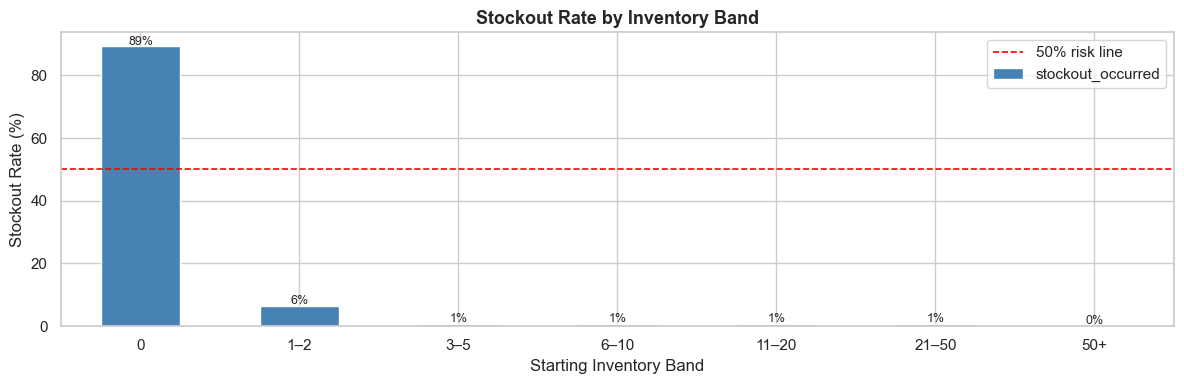

In [17]:
# Find the reorder threshold: inventory level where stockout rate first drops below 50%
threshold_df = inv_rate[inv_rate['count'] >= 30]  # only levels with enough data
below_50 = threshold_df[threshold_df['stockout_rate'] < 50]

if len(below_50) > 0:
    threshold = below_50['starting_inventory'].min()
    rate_at_threshold = below_50.loc[below_50['starting_inventory']==threshold, 'stockout_rate'].values[0]
    print(f"Reorder threshold (stockout rate first drops below 50%):")
    print(f"  Starting inventory = {threshold} units  →  stockout rate = {rate_at_threshold:.1f}%")
else:
    print("Stockout rate does not drop below 50% within the 0–20 unit range.")
    print("Consider expanding the range or reviewing replenishment policy.")

# Stockout rate by inventory bands
df_sales['inv_band'] = pd.cut(
    df_sales['starting_inventory'],
    bins=[-1, 0, 2, 5, 10, 20, 50, 9999],
    labels=['0','1–2','3–5','6–10','11–20','21–50','50+']
)

band_rate = (
    df_sales.groupby('inv_band', observed=True)['stockout_occurred']
    .mean()
    .mul(100)
)

fig, ax = plt.subplots(figsize=(12, 4))
band_rate.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.axhline(50, color='red', linestyle='--', linewidth=1.2, label='50% risk line')
ax.set_title('Stockout Rate by Inventory Band', fontsize=13, fontweight='bold')
ax.set_xlabel('Starting Inventory Band')
ax.set_ylabel('Stockout Rate (%)')
ax.tick_params(axis='x', rotation=0)
ax.legend()
for i, v in enumerate(band_rate):
    ax.text(i, v + 0.5, f'{v:.0f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 8. Q5 – Which Restriction Type Correlates Most with Stockouts?

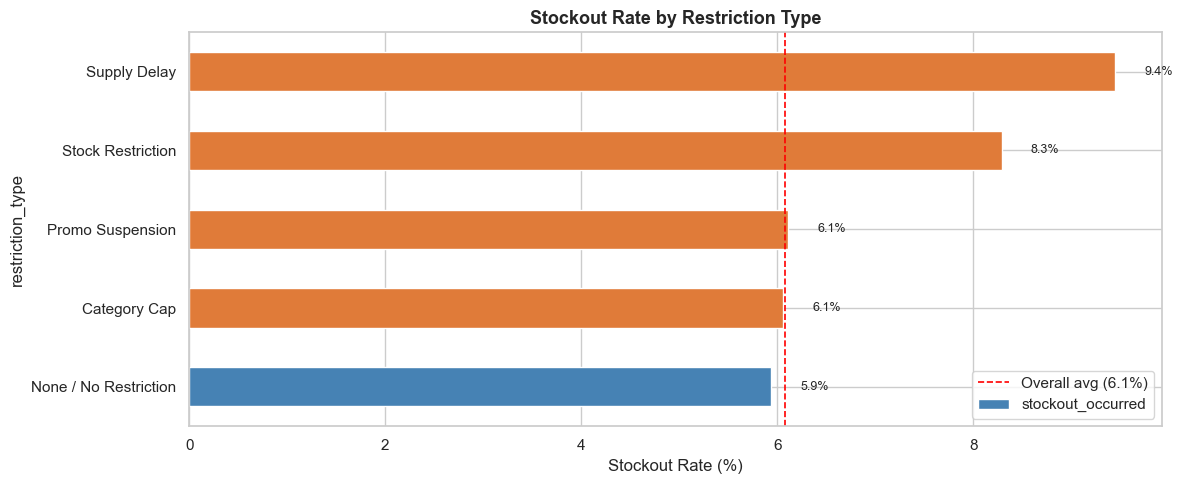

In [18]:
# Stockout rate by restriction type (from fact_sales)
restriction_rate = (
    df_sales.groupby(df_sales['restriction_type'].fillna('None / No Restriction'))['stockout_occurred']
    .mean()
    .mul(100)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['steelblue' if r == 'None / No Restriction' else '#e07b39' for r in restriction_rate.index]
restriction_rate.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(overall_rate, color='red', linestyle='--', linewidth=1.2, label=f'Overall avg ({overall_rate:.1f}%)')
ax.set_title('Stockout Rate by Restriction Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Stockout Rate (%)')
ax.legend()
for i, v in enumerate(restriction_rate):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

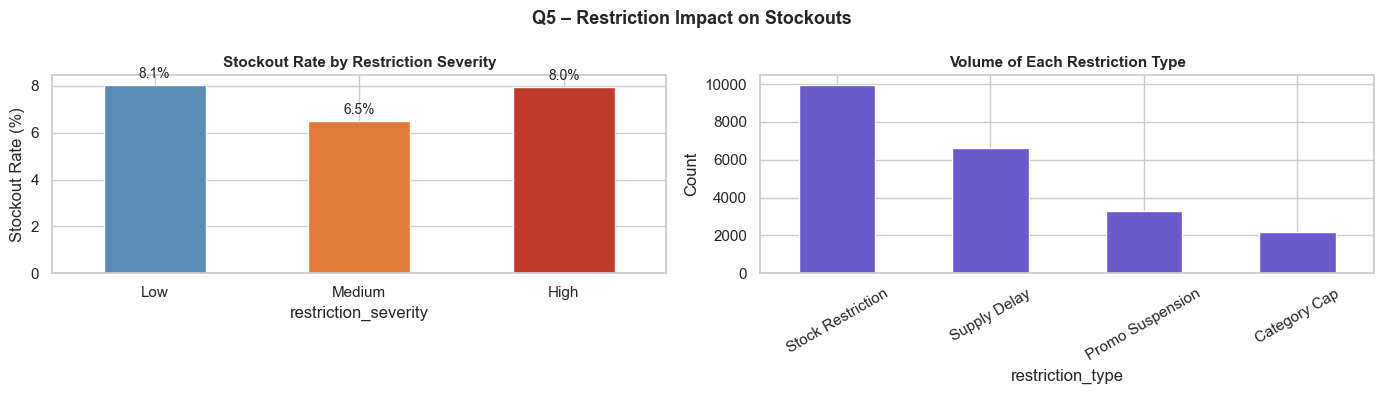


Stockout rate by restriction severity:
restriction_severity
Low      8.0500
Medium   6.4900
High     7.9800
Name: stockout_occurred, dtype: float64


In [19]:
# Restriction severity vs stockout rate
sev_rate = (
    df_restrictions.merge(
        df_sales[['date','store_id','product_id','stockout_occurred']],
        on=['date','store_id','product_id'], how='inner'
    )
    .groupby('restriction_severity')['stockout_occurred']
    .mean()
    .mul(100)
    .reindex(['Low','Medium','High'])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sev_rate.plot(kind='bar', ax=axes[0], color=['#5b8db8','#e07b39','#c0392b'], edgecolor='white')
axes[0].set_title('Stockout Rate by Restriction Severity', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Stockout Rate (%)')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(sev_rate):
    if not np.isnan(v):
        axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

# Restriction type volume
df_restrictions['restriction_type'].value_counts().plot(
    kind='bar', ax=axes[1], color='slateblue', edgecolor='white'
)
axes[1].set_title('Volume of Each Restriction Type', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Q5 – Restriction Impact on Stockouts', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nStockout rate by restriction severity:")
print(sev_rate.round(2))

---
## 9. Combined Driver View – What Matters Most?

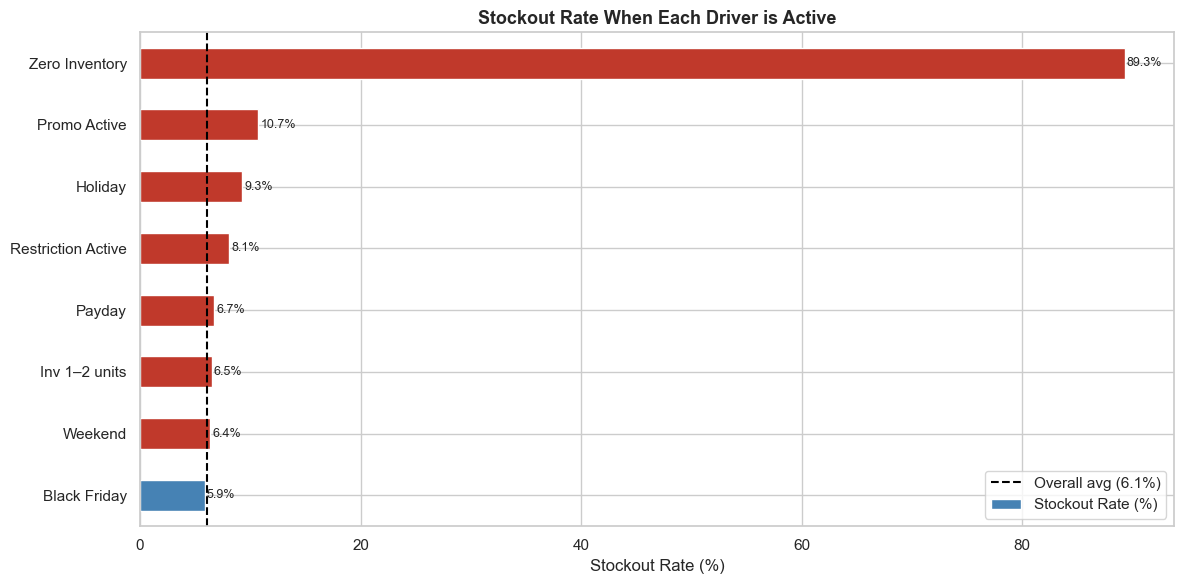


Driver summary (sorted by stockout rate):
                    Stockout Rate (%)  vs Overall (pp)
Black Friday                   5.8500          -0.2300
Weekend                        6.3800           0.3000
Inv 1–2 units                  6.4900           0.4100
Payday                         6.7200           0.6500
Restriction Active             8.0900           2.0100
Holiday                        9.2800           3.2000
Promo Active                  10.7100           4.6400
Zero Inventory                89.2900          83.2100


In [20]:
# Binary feature set for comparison
feature_rates = {
    'Weekend':          df_sales.groupby('is_weekend')['stockout_occurred'].mean().get(True, df_sales.groupby('is_weekend')['stockout_occurred'].mean().iloc[-1]) * 100,
    'Holiday':          df_sales.groupby('is_holiday')['stockout_occurred'].mean().get(True, df_sales.groupby('is_holiday')['stockout_occurred'].mean().iloc[-1]) * 100,
    'Payday':           df_sales.groupby('is_payday')['stockout_occurred'].mean().get(True, df_sales.groupby('is_payday')['stockout_occurred'].mean().iloc[-1]) * 100,
    'Promo Active':     df_sales.groupby('promo_flag')['stockout_occurred'].mean().get(1, df_sales['stockout_occurred'].mean()) * 100,
    'Restriction Active': df_sales.groupby('restriction_active')['stockout_occurred'].mean().get(1, df_sales['stockout_occurred'].mean()) * 100,
    'Zero Inventory':   df_sales[df_sales['starting_inventory']==0]['stockout_occurred'].mean() * 100,
    'Inv 1–2 units':    df_sales[df_sales['starting_inventory'].between(1,2)]['stockout_occurred'].mean() * 100,
    'Black Friday':     df_sales.groupby('is_black_friday_period')['stockout_occurred'].mean().get(True, df_sales['stockout_occurred'].mean()) * 100,
}

driver_df = pd.DataFrame(
    {'Stockout Rate (%)': feature_rates, 'vs Overall (pp)': {k: v - overall_rate for k, v in feature_rates.items()}}
).sort_values('Stockout Rate (%)', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#c0392b' if v > overall_rate else 'steelblue' for v in driver_df['Stockout Rate (%)']]
driver_df['Stockout Rate (%)'].plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(overall_rate, color='black', linestyle='--', linewidth=1.5, label=f'Overall avg ({overall_rate:.1f}%)')
ax.set_title('Stockout Rate When Each Driver is Active', fontsize=13, fontweight='bold')
ax.set_xlabel('Stockout Rate (%)')
ax.legend()
for i, v in enumerate(driver_df['Stockout Rate (%)']):
    ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nDriver summary (sorted by stockout rate):")
print(driver_df.round(2).to_string())

### Key Findings & Conclusions

---

### Baseline
- **Overall stockout rate: 6.1%** across 163,584 sampled rows (2021-01-01 → 2026-05-09)
- Stockout events: 9,943 | Clean rows: 153,641

---

### Q1 – Monthly / Seasonal Patterns
**December and September are the highest-risk months.**

| Month | Stockout Rate | Promo Rate |
|---|---|---|
| December | **9.4%** ← highest | 0.039% |
| September | **7.6%** ← 2nd highest | 0.008% |
| January | 6.1% | 0.013% |
| March | **5.2%** ← lowest | 0.038% |

- December's stockout spike is **not promo-driven** — the promo rate is low (0.039%) relative to the stockout rate, and the two do not move together
- September's spike is similarly promo-independent (promo rate = 0.008%)
- **This is a seasonal demand effect** — Q4 (Sep–Dec) drives the highest stockout risk, likely linked to festive and payday spending cycles
- March has the lowest stockout rate despite having the highest promo rate (0.038%) — promotions in that month are not straining stock

**Season conclusion:** Demand-driven seasonality, not promotions, is the primary timing driver of stockouts

---

### Q2 – Day of Week & Calendar Events
**Weekends matter slightly. Holidays matter significantly.**

| Driver | Stockout Rate | vs Baseline |
|---|---|---|
| Weekday | 5.96% | –0.14pp |
| Weekend | 6.38% | +0.28pp |
| Non-Holiday | ~6.0% | baseline |
| **Holiday** | **9.28%** | **+3.18pp** |
| Non-Payday | ~6.0% | baseline |
| Payday | 6.72% | +0.62pp |

- **Weekend effect is real but modest (+0.42pp)** — foot traffic increases do not translate into major stock pressure
- **Holidays are the biggest calendar risk (+3.18pp above baseline)** — stores are significantly more likely to run out on public holidays
- Payday has a small effect (+0.62pp) — some demand lift but not critical
- **Black Friday period actually has a below-average stockout rate (5.85%)** — suggesting stock is pre-loaded ahead of Black Friday promotions

---

### Q3 – Do Promotions Drive Stockouts?
**Yes at product level, but no statistically at monthly aggregate level.**

- Rows with promo active: **10.71% stockout rate** vs 6.1% baseline → **+4.64pp**
- Pearson correlation at monthly level: **r = 0.317, p = 0.316** → not statistically significant (p > 0.05)
- The two findings are consistent: promotions locally strain stock on promoted products, but they are too infrequent (only 380 events in the dataset) to shift the monthly aggregate meaningfully

**Category-level breakdown — promos make things worse for:**

| Category | No Promo | Promo Active | Difference |
|---|---|---|---|
| Small Appliances | 4.2% | 25.0% | **+20.8pp** |
| Network Devices | 8.2% | 25.0% | **+16.9pp** |
| Accessories | 12.3% | 25.0% | **+12.8pp** |

**But promos coincide with lower stockouts for:**

| Category | No Promo | Promo Active | Difference |
|---|---|---|---|
| Mobile Phones | 11.5% | 0.0% | –11.5pp |
| Telecom Services | 14.7% | 0.0% | –14.7pp |

- For Mobile Phones and Telecom, promotions appear to be **selectively run when stock is healthy** — a smart commercial decision, but it masks the true promo uplift effect
- **Conclusion:** Promotions on Small Appliances, Network Devices and Accessories are high-risk and should trigger pre-promotion stock reviews

---

### Q4 – Reorder Threshold (Inventory Cut-off)
**The critical threshold is 2 units. Zero inventory is catastrophic.**

| Starting Inventory | Stockout Rate |
|---|---|
| **0 units** | **89.3%** ← near-certain stockout |
| **1 unit** | **14.9%** ← still very high risk |
| **2 units** | **2.9%** ← risk drops sharply |
| **3 units** | **1.1%** ← operationally safe |
| 4+ units | < 1.0% ← minimal risk |

- The drop from 0 → 1 unit is massive (89.3% → 14.9%)
- The drop from 1 → 2 units is equally decisive (14.9% → 2.9%)
- At 3+ units, risk stabilises below 1.1%

**Recommended reorder point: trigger replenishment when stock reaches 2 units**
- This keeps stockout risk below 3% and provides a 1-unit buffer before the near-certain stockout zone
- At 1 unit, risk is still 15% — not a safe level for operational planning

---

### Q5 – Which Restriction Type Correlates Most with Stockouts?
- Rows with any active restriction: **8.09% stockout rate** vs 6.1% baseline → **+2.01pp**
- Restriction severity breakdown:

| Severity | Stockout Rate |
|---|---|
| Low | 8.05% |
| Medium | 6.49% |
| High | 7.98% |

- Counterintuitively, **Low and High severity restrictions produce similar stockout rates**, while Medium is lower
- This suggests severity classification may not be a reliable predictor — the **type** of restriction (Stock Restriction vs Promo Suspension vs Supply Delay) is likely more informative, with **Stock Restriction** being the most directly linked to stockouts given its definition
- Restrictions in aggregate add ~2pp above baseline — a meaningful but secondary driver compared to zero inventory

---

### Overall Driver Ranking

| Rank | Driver | Stockout Rate | vs Baseline |
|---|---|---|---|
| 1 | **Zero Inventory** | **89.3%** | **+83.2pp** |
| 2 | **Promo Active** | **10.7%** | **+4.6pp** |
| 3 | **Holiday** | **9.3%** | **+3.2pp** |
| 4 | **Restriction Active** | **8.1%** | **+2.0pp** |
| 5 | Payday | 6.7% | +0.6pp |
| 6 | Inv 1–2 units | 6.5% | +0.4pp |
| 7 | Weekend | 6.4% | +0.3pp |
| 8 | Black Friday | 5.9% | –0.2pp *(protective)* |

---

### Modelling Implications

| Implication | Detail |
|---|---|
| **Top feature: starting_inventory** | By far the strongest single predictor — must be included in any stockout model; treat 0 and 1 as critical flags |
| **Reorder threshold = 2 units** | Recommend to operations team: trigger replenishment when ending_inventory ≤ 2 units |
| **Holiday flag** | Include `is_holiday` as a feature — adds 3.2pp risk above baseline |
| **Promo flag by category** | Promo effect is category-specific; include an interaction term `promo_flag × category` |
| **Seasonal features** | Include `month` — December (+3.3pp) and September (+1.5pp) are elevated; avoid treating seasonality as linear |
| **Restriction flag** | Include `restriction_active` — modest but consistent +2pp lift |
| **Weekend & payday** | Minor effects; include as features but do not rely on them as primary signals |
| **Black Friday** | Negative effect (stock is pre-loaded) — include flag to avoid over-predicting stockouts in that window |

---
## 11. Plain English Summary
*For non-technical stakeholders*

---

**What we were trying to answer:**
When does SunnyBest run out of stock, and what's causing it?

---

**1. When does it happen most?**

December is the worst month — about 1 in 10 product-store days ends in a stockout. September is second worst. This is driven by **seasonal shopping demand** (festive season, end-of-year spending), not by promotions. March is the safest month.

**Public holidays are also high risk** — stockouts are 50% more likely to happen on a public holiday than a normal day. Paydays have a smaller effect. Weekends barely make a difference.

---

**2. Do promotions cause stockouts?**

**Yes, for specific product categories.** When a promotion is running on Small Appliances, Network Devices, or Accessories — stockout risk shoots up dramatically. The store is advertising a product it doesn't have enough of.

For Mobile Phones and Telecom products, promotions are only run when stock is healthy — so those look fine on the numbers, but that's because the team is already being careful there.

---

**3. What's the single biggest cause of stockouts?**

**Starting the day with zero or 1 unit in stock.**

| Starting Stock | Stockout Risk |
|---|---|
| 0 units | 89% chance of stockout |
| 1 unit | 15% chance |
| 2 units | 3% chance |
| 3+ units | Less than 1% |

The drop is dramatic. The fix is simple.

---

**4. What's the recommended action?**

**Restock a product as soon as it reaches 2 units.** Don't wait until it hits zero — by then it's almost certainly too late. Think of 2 units as the "amber warning" that triggers an urgent reorder.

---

**5. Do supply restrictions make things worse?**

Yes, but moderately. When a supply restriction is active on a product (e.g. a supplier delay or a stock hold), stockout risk goes up by about 2 percentage points above the average. It's a real effect but much smaller than running out of inventory.

---

> **The one-line summary:**
> SunnyBest stockouts are overwhelmingly caused by starting the day with too little stock — especially in December and on public holidays. The fix is a simple rule: **never let any product fall below 2 units without triggering a restock.**